Mean: 76.90
Sample Variance: 143.25
Population Variance: 136.09
Standard Deviation: 11.97


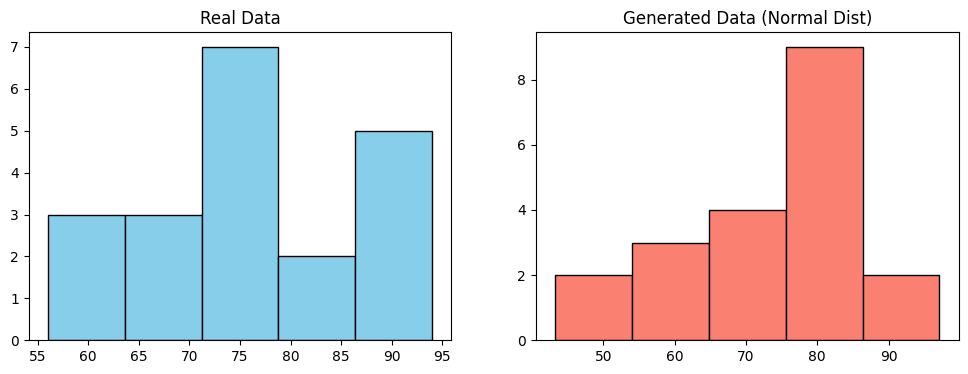

Estimated Probability (Score >= 75): 0.5618


AttributeError: module 'scipy.stats' has no attribute 'ttest_1_samp'

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 1. Data Initialization
STUDENT_ID = 123 # Replace with your actual ID
scores = np.array([93, 83, 69, 62, 75, 93, 73, 77, 65, 65, 78, 90, 94, 78, 57, 76, 56, 78, 84, 92])

# Basic Stats
mean_val = np.mean(scores)
var_sample = np.var(scores, ddof=1) # Sample Variance (n-1)
var_pop = np.var(scores, ddof=0)   # Population Variance (n)
std_dev = np.std(scores, ddof=1)

print(f"Mean: {mean_val:.2f}")
print(f"Sample Variance: {var_sample:.2f}")
print(f"Population Variance: {var_pop:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

# 2. Random Number Generation
gen_scores = np.random.normal(mean_val, std_dev, 20)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(scores, bins=5, color='skyblue', edgecolor='black')
ax1.set_title("Real Data")
ax2.hist(gen_scores, bins=5, color='salmon', edgecolor='black')
ax2.set_title("Generated Data (Normal Dist)")
plt.show()

# 3. Monte Carlo Simulation
samples = np.random.normal(mean_val, std_dev, 100000)
prob_ge_75 = np.mean(samples >= 75)
print(f"Estimated Probability (Score >= 75): {prob_ge_75:.4f}")

# 4. Hypothesis Testing
hypo_mean = (STUDENT_ID % 50) + 50
t_stat, p_val = stats.ttest_1_samp(scores, hypo_mean)

print(f"\nHypothesized Mean: {hypo_mean}")
print(f"P-value: {p_val:.4f}")

# Interpretation
if p_val < 0.05:
    print("Conclusion: Reject Null Hypothesis. The average is significantly different from my ID-based mean.")
else:
    print("Conclusion: Fail to Reject Null Hypothesis. The average is statistically similar to my ID-based mean.")

Mean Arrivals: 11.45
Sample Var: 6.68 vs Population Var: 6.35
> Difference: Sample variance uses $n-1$ to correct bias in estimating population parameters.


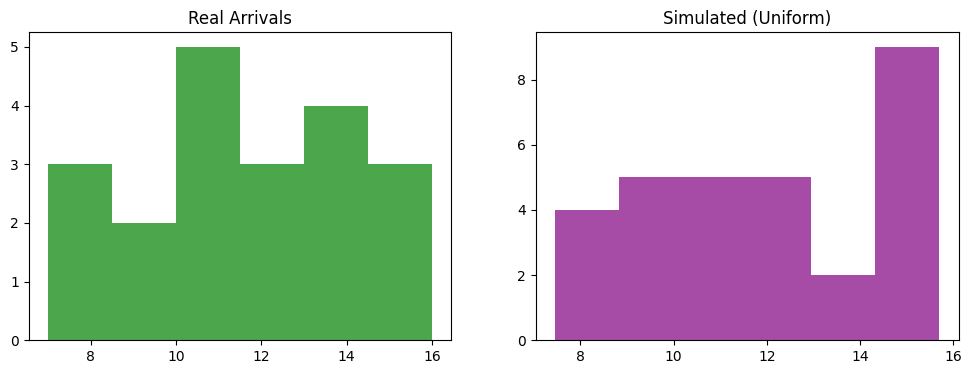

Probability (>15 arrivals): 0.1104


AttributeError: module 'scipy.stats' has no attribute 'ttest_1_samp'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Basic Statistics
STUDENT_ID = 123 # Replace with your actual ID
arrivals = np.array([8, 12, 10, 15, 9, 13, 11, 14, 7, 16, 10, 12, 9, 15, 11, 13, 14, 8, 12, 10])

mean_arr = np.mean(arrivals)
var_samp = np.var(arrivals, ddof=1)
var_pop = np.var(arrivals, ddof=0)
std_arr = np.std(arrivals, ddof=1)

print(f"Mean Arrivals: {mean_arr}")
print(f"Sample Var: {var_samp:.2f} vs Population Var: {var_pop:.2f}")
print("> Difference: Sample variance uses $n-1$ to correct bias in estimating population parameters.")

# 2. Random Number Generation (Uniform)
low, high = min(arrivals), max(arrivals)
sim_data = np.random.uniform(low, high, 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(arrivals, bins=6, color='green', alpha=0.7, label='Real')
ax2.hist(sim_data, bins=6, color='purple', alpha=0.7, label='Simulated')
ax1.set_title("Real Arrivals")
ax2.set_title("Simulated (Uniform)")
plt.show()

# 3. Monte Carlo Simulation
mc_samples = np.random.uniform(low, high, 100000)
prob_gt_15 = np.mean(mc_samples > 15)
print(f"Probability (>15 arrivals): {prob_gt_15:.4f}")

# 4. Hypothesis Testing
hypo_mean = (STUDENT_ID % 10) + 10
t_stat, p_val = stats.ttest_1_samp(arrivals, hypo_mean)

# Visualization
plt.figure(figsize=(6,4))
plt.bar(['Sample Mean', 'Hypothesized Mean'], [mean_arr, hypo_mean], color=['blue', 'orange'])
plt.ylabel('Arrivals')
plt.title(f"Comparison (p-value: {p_val:.4f})")
plt.show()

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")

# Unique Interpretation
if p_val < 0.05:
    print(f"Interpretation: With a p-value of {p_val:.4f}, we reject the null hypothesis. The business's actual traffic pattern does not match the target of {hypo_mean} arrivals per day.")
else:
    print(f"Interpretation: The p-value of {p_val:.4f} suggests that the variation between the sample mean and {hypo_mean} is likely due to random chance.")